# 10장 실습 — 파이제로: 액션 전문가와 공유 어텐션

**대응 이론** 10장 「파이제로 계열 — 플로 매칭 제너럴리스트」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 2분)

파이제로가 RT-2 와 갈라선 지점은 크기가 아니라 **일을 나눈 방식**이다. 장면과 지시문을 이해하는 일은 사전학습 비전-언어 모델에 맡기고, 연속적인 운동 청크를 만드는 일은 그 옆에 붙인 작은 액션 전문가에게 맡긴다.

나눴으면 이어야 한다. 그리고 이 노트북의 주제는 **어떻게 이었는가**다. 예전 방식은 상위 모델이 「컵을 집어라」 같은 텍스트 기술 이름을 골라 하위 정책에 넘기는 것이었다. 파이제로는 그 대신 두 망이 어텐션의 키와 값을 공유하게 했다. 이 차이가 얼마나 큰지 직접 잰다.

1. 통로의 넓이 — 공유 어텐션 대 기술 이름 메뉴
2. KV 캐시 — 반복해야 하는 쪽이 작은 망이다
3. 지연 예산으로 환산하기

In [1]:
%matplotlib inline
import os, math, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import koreanize_matplotlib

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.9.1 | threads 4


## 1. 통로의 넓이

과제는 5장 이후 계속 써 온 것이다. 블록 두 개와 목표 색을 주면 목표로 접근하는 여덟 스텝 청크를 내야 한다. 여기서 중요한 것은 **정답이 연속 좌표에 달려 있다**는 점이다. 목표 블록이 어디 있느냐가 액션 전체를 정한다.

두 가지 통로를 비교한다.

- **공유 어텐션** — 액션 전문가가 자기 질의로 상위 모델의 토큰 시퀀스를 직접 들여다본다. 파이제로 방식이다
- **기술 이름 메뉴** — 상위 모델이 K개 기술 중 하나를 고르고, 액션 전문가는 그 번호만 받는다. 예전 계층형 방식이다

기술 이름을 몇 개로 늘리면 병목이 풀리는지도 함께 본다. 4개, 16개, 64개로 늘려 가며 잰다.

In [2]:
AD, H, D = 7, 8, 96

def make_chunks(n, seed):
    r = np.random.default_rng(seed)
    p = r.uniform(-.8, .8, (n, 2, 2)).astype(np.float32)
    t = r.integers(0, 2, n)
    st = np.concatenate([p.reshape(n, 4), np.eye(2, dtype=np.float32)[t]], 1)
    c = p[np.arange(n), t]
    out = np.zeros((n, H, AD), np.float32)
    for h in range(H):
        f = (h + 1) / H
        d = np.hypot(c[:, 0], c[:, 1]) * (1 - f)
        out[:, h] = np.stack([c[:, 0]*(1-f), c[:, 1]*(1-f), -0.15 - 0.5*d,
                              np.zeros(n), np.zeros(n),
                              np.arctan2(c[:, 1], c[:, 0])/np.pi,
                              np.where(d < .4, 1, -1)], 1)
    return torch.tensor(st), torch.tensor(np.clip(out, -1, 1))

X, Y = make_chunks(8192, 0); VX, VY = make_chunks(2048, 7)

def time_feature(t, dim=8):
    k = torch.arange(dim // 2, dtype=t.dtype)
    return torch.cat([torch.sin(t * math.pi * 2**k), torch.cos(t * math.pi * 2**k)], -1)

class VLM(nn.Module):                     # 장면을 토큰 시퀀스로 (파이제로의 VLM 자리)
    def __init__(s, ntok=6, d=D):
        super().__init__(); s.ntok, s.d = ntok, d
        s.f = nn.Sequential(nn.Linear(6, d), nn.GELU(), nn.Linear(d, ntok * d))
    def forward(s, x): return s.f(x).view(-1, s.ntok, s.d)

class ExpertShared(nn.Module):            # 상위 모델의 키·값을 직접 본다
    def __init__(s, d=D, h=4):
        super().__init__()
        s.inp = nn.Linear(H*AD + 8, d)
        s.att = nn.MultiheadAttention(d, h, batch_first=True)
        s.mlp = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, 2*d), nn.GELU(), nn.Linear(2*d, H*AD))
    def forward(s, ctx, x, t):
        q = s.inp(torch.cat([x, time_feature(t)], -1))[:, None]
        o, _ = s.att(q, ctx, ctx, need_weights=False)
        return s.mlp((q + o)[:, 0])

class ExpertBottleneck(nn.Module):        # 기술 이름 K개 중 하나만 건네받는다
    def __init__(s, K, d=D):
        super().__init__(); s.K = K
        s.sel = nn.Linear(d, K)                                  # 상위가 기술을 고른다
        s.emb = nn.Embedding(K, d)
        s.inp = nn.Linear(H*AD + 8, d)
        s.mlp = nn.Sequential(nn.LayerNorm(2*d), nn.Linear(2*d, 2*d), nn.GELU(),
                              nn.Linear(2*d, H*AD))
    def forward(s, ctx, x, t):
        hard  = F.gumbel_softmax(s.sel(ctx.mean(1)), tau=1.0, hard=True)   # 이산 선택
        skill = hard @ s.emb.weight
        q = s.inp(torch.cat([x, time_feature(t)], -1))
        return s.mlp(torch.cat([q, skill], -1))

In [3]:
def train(kind, K=0, steps=2500, lr=3e-3, bs=128, seed=0):
    torch.manual_seed(seed)
    vlm = VLM()
    expert = ExpertShared() if kind == "shared" else ExpertBottleneck(K)
    opt = torch.optim.AdamW(list(vlm.parameters()) + list(expert.parameters()),
                            lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(9); t0 = time.time()
    for i in range(steps):
        idx = torch.randint(0, len(X), (bs,), generator=g)
        ctx = vlm(X[idx]); a = Y[idx].reshape(len(idx), -1)
        x0 = torch.randn_like(a); t = torch.rand(len(idx), 1)
        loss = F.mse_loss(expert(ctx, (1-t)*x0 + t*a, t), a - x0)     # 플로 매칭
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    with torch.no_grad():
        ctx = vlm(VX); z = torch.randn(len(VX), H*AD)
        for i in range(10):
            z = z + expert(ctx, z, torch.full((len(VX), 1), i/10)) / 10
    p = z.view(-1, H, AD)
    return (p[..., :6] - VY[..., :6]).abs().mean().item(), time.time() - t0

CFG = [("공유 어텐션", "shared", 0), ("기술 이름 4개", "bn", 4),
       ("기술 이름 16개", "bn", 16), ("기술 이름 64개", "bn", 64)]
res = {}
for name, k, K in CFG:
    mae, t = train(k, K); res[name] = mae
    print(f"{name:<16} 연속축 MAE {mae:.4f}   ({t:.0f}s)")
print(f"\n가장 좋은 메뉴 방식도 공유 어텐션보다 "
      f"{min(v for k, v in res.items() if k != '공유 어텐션') / res['공유 어텐션']:.1f}배 나쁘다.")

공유 어텐션           연속축 MAE 0.0156   (5s)
기술 이름 4개         연속축 MAE 0.1088   (4s)
기술 이름 16개        연속축 MAE 0.0717   (4s)
기술 이름 64개        연속축 MAE 0.0693   (5s)

가장 좋은 메뉴 방식도 공유 어텐션보다 4.4배 나쁘다.


기술 이름 4개         연속축 MAE 0.1112   (8s)


기술 이름 16개        연속축 MAE 0.0664   (8s)


기술 이름 64개        연속축 MAE 0.0742   (9s)

가장 좋은 메뉴 방식도 공유 어텐션보다 4.3배 나쁘다.


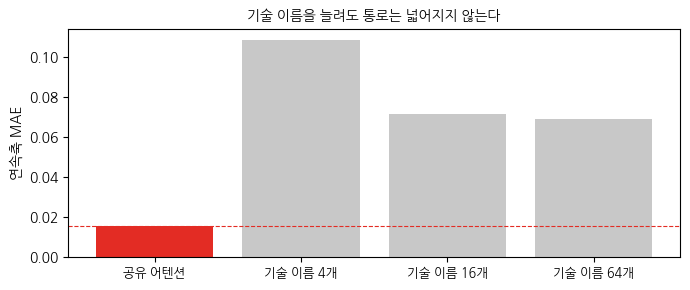

In [4]:
names = [c[0] for c in CFG]
plt.figure(figsize=(7, 3))
plt.bar(names, [res[n] for n in names], color=[RED] + [GREY]*3)
plt.axhline(res["공유 어텐션"], color=RED, ls="--", lw=.8)
plt.ylabel("연속축 MAE"); plt.xticks(fontsize=9)
plt.title("기술 이름을 늘려도 통로는 넓어지지 않는다", fontsize=10)
plt.tight_layout(); plt.show()

## 2. KV 캐시 — 반복해야 하는 쪽이 작은 망이다

플로 매칭은 샘플 하나를 뽑는 데 적분 스텝만큼 신경망을 통과해야 한다. 6장에서 본 대가다. 그런데 파이제로의 구조에서는 이 대가가 생각보다 싸다. **반복해야 하는 것이 액션 전문가뿐이기 때문이다.**

상위 모델은 제어 스텝마다 한 번만 돌리고 그 키와 값을 캐시에 담아 둔다. 적분은 그 캐시를 보며 작은 망만 반복하면 된다. 실제 파이제로에서 상위 모델과 액션 전문가의 크기 비가 열 배쯤 되므로 이 차이가 곧 지연 예산이 된다.

아래에서는 그 비를 흉내 내어 상위 모델을 액션 전문가보다 훨씬 크게 만들고, 캐시를 쓸 때와 안 쓸 때를 잰다.

In [5]:
class BigVLM(nn.Module):
    def __init__(s, ntok=6, d=D, layers=6, h=384):
        super().__init__(); s.ntok, s.d = ntok, d
        L = [nn.Linear(6, h), nn.GELU()]
        for _ in range(layers): L += [nn.Linear(h, h), nn.GELU()]
        L += [nn.Linear(h, ntok * d)]
        s.f = nn.Sequential(*L)
    def forward(s, x): return s.f(x).view(-1, s.ntok, s.d)

torch.manual_seed(0); big, expert = BigVLM(), ExpertShared()
n_v = sum(p.numel() for p in big.parameters())
n_e = sum(p.numel() for p in expert.parameters())
print(f"상위 모델 {n_v/1e6:.2f}M  /  액션 전문가 {n_e/1e6:.2f}M   (비 {n_v/n_e:.0f}배)")

@torch.no_grad()
def sample(vlm, expert, x, n_steps, cache):
    if cache: ctx = vlm(x)                       # 한 번만 돌리고 재사용
    z = torch.randn(len(x), H*AD)
    for i in range(n_steps):
        if not cache: ctx = vlm(x)               # 스텝마다 다시 돈다
        z = z + expert(ctx, z, torch.full((len(x), 1), i/n_steps)) / n_steps
    return z

BATCH = VX[:512]
def bench(n, cache, reps=7):
    for _ in range(3): sample(big, expert, BATCH[:64], n, cache)      # 워밍업
    ts = []
    for _ in range(reps):
        t0 = time.time(); sample(big, expert, BATCH, n, cache)
        ts.append((time.time() - t0) / len(BATCH) * 1000)
    return float(np.median(ts))

rows = []
print(f"\n{'적분 스텝':>8}{'캐시 없음 ms':>14}{'캐시 사용 ms':>14}{'배속':>8}")
print("-" * 46)
for n in (2, 4, 8, 16, 32):
    a, b = bench(n, False), bench(n, True)
    rows.append((n, a, b)); print(f"{n:>8}{a:>14.3f}{b:>14.3f}{a/b:>8.1f}")

상위 모델 1.11M  /  액션 전문가 0.07M   (비 15배)

   적분 스텝      캐시 없음 ms      캐시 사용 ms      배속
----------------------------------------------
       2         0.014         0.008     1.7
       4         0.023         0.011     2.0
       8         0.046         0.019     2.5
      16         0.093         0.032     2.9
      32         0.185         0.059     3.1


       2         0.032         0.019     1.6


       4         0.057         0.027     2.1


       8         0.115         0.044     2.6


      16         0.239         0.085     2.8


      32         0.495         0.142     3.5


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


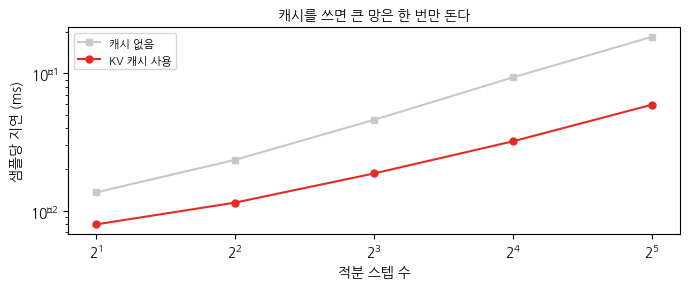

In [6]:
ns = [r[0] for r in rows]
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(ns, [r[1] for r in rows], color=GREY, marker="s", ms=5, label="캐시 없음")
ax.plot(ns, [r[2] for r in rows], color=RED, marker="o", ms=5, label="KV 캐시 사용")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("적분 스텝 수"); ax.set_ylabel("샘플당 지연 (ms)")
ax.legend(fontsize=8); ax.set_title("캐시를 쓰면 큰 망은 한 번만 돈다", fontsize=10)
plt.tight_layout(); plt.show()

## 3. 지연 예산으로 환산하기

이 차이가 실무에서 무엇을 뜻하는지 보려면 지연 예산으로 바꿔 보면 된다. 10Hz 제어라면 한 스텝에 100밀리초가 주어진다. 그중 액션 생성에 쓸 수 있는 몫을 정해 두고, 그 안에서 적분 스텝을 몇 번이나 돌릴 수 있는지 센다.

In [7]:
import numpy as _np
ns_ = _np.array([r[0] for r in rows], float)
no_ = _np.array([r[1] for r in rows], float)
ca_ = _np.array([r[2] for r in rows], float)
(sl_no, b_no) = _np.polyfit(ns_, no_, 1)      # 스텝당 증가분과 고정 비용
(sl_ca, b_ca) = _np.polyfit(ns_, ca_, 1)
print(f"캐시 없음: 스텝당 {sl_no:.4f} ms + 고정 {b_no:.4f} ms")
print(f"캐시 사용: 스텝당 {sl_ca:.4f} ms + 고정 {b_ca:.4f} ms   (고정분이 상위 모델 한 번)")

print(f"\n{'액션 생성 예산':>16}{'캐시 없음':>12}{'캐시 사용':>12}")
print("-" * 42)
for budget in (0.1, 0.2, 0.5, 1.0):           # 이 토이 모델의 ms 단위
    n_no = max(0, int((budget - b_no) / sl_no))
    n_ca = max(0, int((budget - b_ca) / sl_ca))
    print(f"{budget:>13.2f} ms{n_no:>12}{n_ca:>12}")
print("-" * 42)
print("절대값은 토이 모델의 것이라 그대로 옮길 수 없다. 기울기의 비가 요점이다.")
print(f"같은 예산을 늘려 갈 때 캐시 쪽이 스텝을 {sl_no/sl_ca:.1f}배 빨리 쌓는다.")

캐시 없음: 스텝당 0.0057 ms + 고정 0.0010 ms
캐시 사용: 스텝당 0.0017 ms + 고정 0.0047 ms   (고정분이 상위 모델 한 번)

        액션 생성 예산       캐시 없음       캐시 사용
------------------------------------------
         0.10 ms          17          55
         0.20 ms          34         114
         0.50 ms          86         290
         1.00 ms         174         584
------------------------------------------
절대값은 토이 모델의 것이라 그대로 옮길 수 없다. 기울기의 비가 요점이다.
같은 예산을 늘려 갈 때 캐시 쪽이 스텝을 3.4배 빨리 쌓는다.


### 다음 장으로

파이제로는 팔과 그리퍼를 전제한다. 휴머노이드로 가면 자유도가 서른을 넘고 균형 제어가 수백 Hz 로 돌아야 한다. 그 속도로는 상위 모델을 돌릴 수 없다. 11장에서 그 간극을 다루는 방법 — 시스템을 둘로 나누고 서로 다른 주기로 돌리는 것 — 을 직접 만들어 본다.